In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [4]:
df = pd.read_csv("Expectation Decider Data.csv")
print(df.head())

   study_hours  attendance group_discussion  previous_test_score  \
0           22          57              Yes                   87   
1            9          64              Yes                   47   
2           23          97               No                  100   
3           20          77              Yes                   85   
4            8          64              Yes                   41   

  final_exam_pass  
0            Pass  
1            Fail  
2            Pass  
3            Pass  
4            Fail  


# 1. Under Standing The Basics

### What is Probability ?
###### Probability is the measure of the likelihood that a particular event will occur. It quantifies uncertainly using a number between 0 and 1.
###### 0 -> Impossible Event
###### 1 -> Possible Event

### Key Probability Terminology
###### Experiment : An action with uncertain results.
###### Outcome : A possibel result of an experiment.
###### Sample Space : The set of all possible outcomes.
###### Event : An event is a group or collection of outcomes.
###### Favourable Outcome : The specific outcomes that match the desired event.

### Probability Event Examples from Dataset

In [8]:
# Event 1 
event1 = df[df["final_exam_pass"] == "Pass"]

# Event 2
event2 = df[df["study_hours"] > 20]

# Event 3
event3 = df[df["previous_test_score"] == 100]

print("Students Passed:", len(event1))
print("Students Studied >20 Hours:", len(event2))
print("Students with 100 marks in Previous Test:", len(event3))

Students Passed: 114
Students Studied >20 Hours: 45
Students with 100 marks in Previous Test: 44


# 2.Types of Events

### Theoretical Probability
###### - Probability based on mathematical logic and the assumption that all outcomes are equally likely. No data collection in required.
###### ex. Student's Exam Result 
######     Total Outcomes = Pass or Fail

In [10]:
theoretical_probability = 1/2
print("Theoretical Orobability of students exam result : ", theoretical_probability)
print("Students have 50% probability of passing and 50% probability of failing.")

Theoretical Orobability of students exam result :  0.5
Students have 50% probability of passing and 50% probability of failing.


### Empirical Probability
###### - Probability based on real-world data or actual observations from experiments or datasets.
###### ex. Probability that a student passes exam. 

In [15]:
# Total Passed Students
passed_stds = (df["final_exam_pass"] == "Pass").sum()
print("Total Passed Students: ",passed_stds)

# Total Students 
total_stds = len(df)
print("Total Students: ",total_stds)

# Empirical Probability
empirical_probability = passed_stds/total_stds

print("Empirical Probability of student passes exam: ",empirical_probability)

Total Passed Students:  114
Total Students:  200
Empirical Probability of student passes exam:  0.57


# 3. Random Variable & Probability Distribution

#### Define a Random Variable
###### X = Number of students passing exam among 3 randomly selected students.

#### Probability Distribution Table

In [20]:
# Probability of passing
p = empirical_probability

# Probability of failing
q = 1 - p

# Probability distribution table
dist_df = pd.DataFrame({
    'X': [0, 1, 2, 3],

    'P(X)': [
        q**3,              # 0 students pass (q q q)
        3*p*(q**2),        # 1 student passes (p q q)
        3*(p**2)*q,        # 2 students pass (p p q)
        p**3               # 3 students pass (p p p)
    ]
})

print(dist_df)

   X      P(X)
0  0  0.079507
1  1  0.316179
2  2  0.419121
3  3  0.185193


#### Mean and Variance of Random Variable

In [22]:
# μ(mean) = np
mean = 3 * p
print("Mean of Random Variable: ",mean)


# σ2(variance) = npq
variance = 3*p*q
print("Vaiance of Random Variable: ",variance) 

Mean of Random Variable:  1.71
Vaiance of Random Variable:  0.7353000000000001


# 4. Venn Diagram in Probability

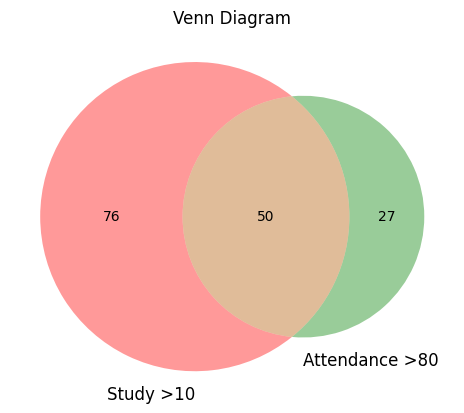

In [29]:
# Students who studied more than 10 hours
study = set(df[df['study_hours'] > 10].index)

# Students whose attendance is more than 80
attendance = set(df[df['attendance'] > 80].index)

# Create Venn Diagram
venn2([study, attendance],
      set_labels=('Study >10', 'Attendance >80'))

plt.title("Venn Diagram")
plt.show()

# 5. Contingency Table & Probability Calculations

##### Contingency Table

In [24]:
contingency_table = pd.crosstab(
    df["group_discussion"],
    df["final_exam_pass"],
    margins = True
)

print(contingency_table)

final_exam_pass   Fail  Pass  All
group_discussion                 
No                  33    39   72
Yes                 53    75  128
All                 86   114  200


#### Joint Probability

In [30]:
both = df[
    (df['group_discussion'] == 'Yes') &
    (df['final_exam_pass'] == 'Pass')
]

joint_probability = len(both) / len(df)

print("Joint Probability: ",joint_probability)

Joint Probability:  0.375


#### Marginal Probability

In [31]:
passed = df[df['final_exam_pass'] == 'Pass']

marginal_probability = len(passed) / len(df)

print("Marginal Probability: ",marginal_probability)

Marginal Probability:  0.57


#### Conditional Probabililty

In [33]:
both = df[
    (df["group_discussion"] == "Yes") &
    (df["final_exam_pass"] == "Fail")
    ]

fail = df[df["final_exam_pass"] == "Fail"]

conditional_probability = len(both)/len(fail)

print("Conditional Probability: ",conditional_probability)

Conditional Probability:  0.6162790697674418


# 7. Bayes Theorem

In [34]:
pass_high_pro = 0.70

pass_pro = empirical_probability

high_pro = 0.60

bayes_probability = (pass_high_pro * pass_pro) / high_pro

print("Probability of Passing Given High Attendance =", bayes_probability)

Probability of Passing Given High Attendance = 0.6649999999999999
